# Tracking Political Change with Embeddings of Parliamentary Speeches
### 0. Imports & Paths
The following datasets were collected to analyse our research question
- Open Discourse Bundestag Dataset (covering 1949-2021)
- Chapel Expert Survey
- Manifesto Project

In [ ]:
# Imports and Paths
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")

### 1. Load the raw data

In [ ]:
speeches = pd.read_csv(RAW / "speeches.csv")
ches = pd.read_csv(RAW / "CHES.csv")
manifesto = pd.read_csv(RAW / "manifesto.csv")

# Auxiliary Open Discourse table
factions = pd.read_csv(RAW / "factions.csv")

print("speeches:", speeches.shape)
print("ches:", ches.shape)
print("manifesto:", manifesto.shape)
print("factions:", factions.shape)

speeches: (907644, 12)
ches: (1441, 90)
manifesto: (5285, 175)
factions: (28, 3)


/var/folders/s5/fy91nyld24n09t7z3kdvvvzh0000gn/T/ipykernel_40944/1023499878.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  manifesto = pd.read_csv(RAW / "manifesto.csv")


### 2. Preprocessing

Three raw sources are cleaned and filtered here, one after another:

- **2.1 Speeches** — Open Discourse Bundestag speeches (main + fine-tuning slices)
- **2.2 CHES** — Chapel Hill Expert Survey (Germany, selected ideology columns)
- **2.3 Manifesto** — Manifesto Project (Germany, 1994-2021, RILE score)

Each writes its own file in Section 5.

#### 2.1 Speeches

We build two datasets from the raw Open Discourse speeches and apply exactly the same pipeline.

- **Main dataset (2000-2021)** is the corpus we embed with our chosen encoder.
- **Fine-tuning dataset (1995-1999)** is used *only* to fine-tune the encoder itself.

**Decisions applied to both datasets**

- **Speaker filter.** Drop rows with `factionId == -1` (chairing turns, ministerial statements, guest speakers) so only party-affiliated MP speeches remain.
- **Text cleaning.** Strip Open Discourse interjection markers like `({0})`, unwrap PDF line wraps, drop orphan dashes, and flatten to a single line so the tokenizer sees actual speech content.
- **Tokenization.** Jina v3 multilingual tokenizer (XLM-R based, 8192-token context) so lengths reflect the exact units the encoder will see.
- **Length floor.** Drop speeches under 100 tokens (interjections, procedural remarks).
- **Length ceiling.** Truncate speeches longer than 8192 tokens to fit the Jina v3 context.
- **Party names.** Attach the human-readable abbreviation via `factions.csv` and normalise inconsistent labels (e.g. `DIE LINKE.` → `LINKE`).
- **Politician names.** Strip whitespace on `firstName` / `lastName` and add a combined `politicianName` column for display; `politicianId` is the stable key.

In [ ]:
# Parse dates and split into the two working windows
speeches["date"] = pd.to_datetime(speeches["date"], errors="coerce")

WINDOWS = {
    "main": ("2000-01-01", "2021-12-31"),
    "finetune": ("1995-01-01", "1999-12-31"),
}

datasets = {
    name: speeches[(speeches["date"] >= start) & (speeches["date"] <= end)].copy()
    for name, (start, end) in WINDOWS.items()
}

for name, df in datasets.items():
    start, end = WINDOWS[name]
    print(f"{name:>8}: {len(df):>7,} speeches ({start} to {end})")

    main: 303,199 speeches (2000-01-01 to 2021-12-31)
finetune:  73,668 speeches (1995-01-01 to 1999-12-31)


In [ ]:
speeches["positionLong"]

0                        präsident
1         präsident des bundesrats
2                        präsident
3                  bundespräsident
4                        präsident
                    ...           
907639                         NaN
907640             Vizepräsidentin
907641                         NaN
907642             Vizepräsidentin
907643                         NaN
Name: positionLong, Length: 907644, dtype: object

In [ ]:
# Ignore unmatched factions (-1): chairing turns, ministerial statements, guests
for name, df in datasets.items():
    datasets[name] = df[df["factionId"] != -1].copy()
    print(f"{name:>8}: {len(datasets[name]):>7,} speeches remain after dropping factionId -1")

    main: 135,640 speeches remain after dropping factionId -1
finetune:  31,681 speeches remain after dropping factionId -1


In [ ]:
# Text cleaning — run before tokenization so token counts reflect the actual speech.
#  - `({0})`, `({1})`, ... are Open Discourse interjection markers, not spoken text.
#  - Raw text keeps the PDF's line wrapping ("den\nneuen", "Wort-\nfortsetzung");
#    we unwrap those into normal running text.
#  - After Open Discourse strips interjections we're often left with orphan dashes
#    around what used to be `– Zwischenruf … –` blocks; drop those.
#  - Paragraph structure carries no signal for the embedding model, so the final
#    text is a single flat line (paragraphs joined with a space).

_INTERJECTION_MARKER = re.compile(r"\(\{\d+\}\)")
_PARAGRAPH_BREAK     = re.compile(r"\n{2,}")
_HYPHEN_LINEBREAK    = re.compile(r"-\n(?=\w)")     # "Wort-\nfortsetzung" -> "Wortfortsetzung"
_SOFT_LINEBREAK      = re.compile(r"\s*\n\s*")      # any single line wrap -> space
_MULTI_SPACE         = re.compile(r"\s{2,}")
_EDGE_DASHES         = re.compile(r"^[-–—\s]+|[-–—\s]+$")   # strip leading/trailing dashes
_HAS_WORD            = re.compile(r"\w")

def clean_text(text: str) -> str:
    text = _INTERJECTION_MARKER.sub("", text)

    parts = []
    for para in _PARAGRAPH_BREAK.split(text):
        para = _HYPHEN_LINEBREAK.sub("", para)
        para = _SOFT_LINEBREAK.sub(" ", para)
        para = _EDGE_DASHES.sub("", para)
        para = _MULTI_SPACE.sub(" ", para).strip()
        if para and _HAS_WORD.search(para):
            parts.append(para)
    return " ".join(parts)

for name, df in datasets.items():
    df["speechContent"] = df["speechContent"].fillna("").map(clean_text)
    datasets[name] = df
    empty_after = (df["speechContent"] == "").sum()
    print(f"{name:>8}: cleaned {len(df):,} speeches "
          f"({empty_after} empty after cleaning)")

    main: cleaned 135,640 speeches (15 empty after cleaning)
finetune: cleaned 31,681 speeches (0 empty after cleaning)


In [ ]:
# Tokenize with the Jina v3 multilingual tokenizer (XLM-R based, 8192 ctx)
# so the length distribution reflects the exact units the model will see.
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("jinaai/jina-embeddings-v3", trust_remote_code=True)
print(f"Tokenizer max length: {tok.model_max_length}\n")

BATCH = 256

def _token_lengths(texts):
    out = []
    for i in range(0, len(texts), BATCH):
        enc = tok(texts[i:i + BATCH], add_special_tokens=True,
                  truncation=False, padding=False)
        out.extend(len(x) for x in enc["input_ids"])
    return out

for name, df in datasets.items():
    print(f"Tokenizing {name} ({len(df):,} speeches)…")
    df["n_tokens"] = _token_lengths(df["speechContent"].fillna("").tolist())
    datasets[name] = df
    print(f"  done — {name} n_tokens: min={df['n_tokens'].min()}, "
          f"median={int(df['n_tokens'].median())}, max={df['n_tokens'].max()}")

`torch_dtype` is deprecated! Use `dtype` instead!


Tokenizer max length: 8194

Tokenizing main (135,640 speeches)…


Token indices sequence length is longer than the specified maximum sequence length for this model (9449 > 8194). Running this sequence through the model will result in indexing errors


  done — main n_tokens: min=2, median=676, max=9449
Tokenizing finetune (31,681 speeches)…
  done — finetune n_tokens: min=3, median=213, max=10577


In [ ]:
# Full length distribution for each dataset
for name, df in datasets.items():
    print(f"\n=== {name} — token distribution ===")
    print(df["n_tokens"].describe(
        percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))


=== main — token distribution ===
count    135640.000000
mean        717.743615
std         654.466274
min           2.000000
1%            4.000000
5%           10.000000
10%          33.000000
25%         117.000000
50%         676.000000
75%        1129.000000
90%        1539.000000
95%        1857.000000
99%        2572.000000
max        9449.000000
Name: n_tokens, dtype: float64

=== finetune — token distribution ===
count    31681.000000
mean       618.300054
std        795.917659
min          3.000000
1%           4.000000
5%           6.000000
10%         17.000000
25%         72.000000
50%        213.000000
75%        998.000000
90%       1712.000000
95%       2175.000000
99%       3354.000000
max      10577.000000
Name: n_tokens, dtype: float64


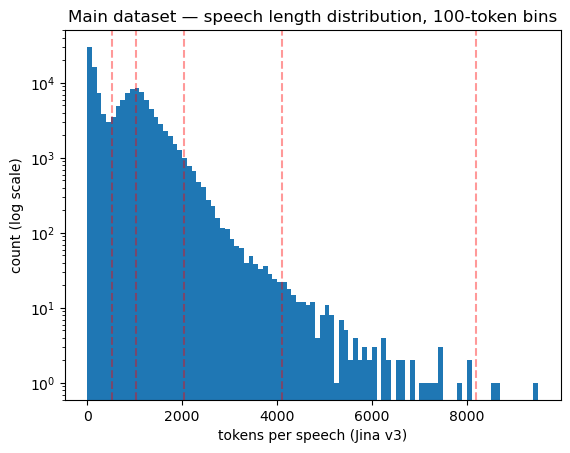


main — share of speeches below threshold:
  under   10 tokens:  4.6%
  under   15 tokens:  6.2%
  under   20 tokens:  7.4%
  under   30 tokens:  9.3%
  under   50 tokens: 12.9%
  under  100 tokens: 22.2%
  under  200 tokens: 34.2%
  under  500 tokens: 44.8%

finetune — share of speeches below threshold:
  under   10 tokens:  7.4%
  under   15 tokens:  9.4%
  under   20 tokens: 10.5%
  under   30 tokens: 12.6%
  under   50 tokens: 17.8%
  under  100 tokens: 33.0%
  under  200 tokens: 49.1%
  under  500 tokens: 61.1%


In [ ]:
# Histogram of speech lengths (main dataset) with common model context caps marked,
# plus short-tail shares for both datasets to inform the min-length filter.
main = datasets["main"]
top = main["n_tokens"].max()
plt.hist(main["n_tokens"], bins=range(0, top + 100, 100))
plt.yscale("log")
plt.xlabel("tokens per speech (Jina v3)"); plt.ylabel("count (log scale)")
plt.title("Main dataset — speech length distribution, 100-token bins")
for cap in [512, 1024, 2048, 4096, 8192]:
    plt.axvline(cap, color="red", linestyle="--", alpha=0.4)
plt.show()

for name, df in datasets.items():
    print(f"\n{name} — share of speeches below threshold:")
    for t in [10, 15, 20, 30, 50, 100, 200, 500]:
        print(f"  under {t:>4} tokens: {(df['n_tokens'] < t).mean():5.1%}")

In [ ]:
# Examples of very short speeches (< 30 tokens) — mostly interjections / procedural
short = datasets["main"].loc[datasets["main"]["n_tokens"] < 30,
                             ["n_tokens", "speechContent"]]
print(f"{len(short):,} speeches under 30 tokens\n")

for i, (n, txt) in enumerate(short.head(15).itertuples(index=False), 1):
    print(f"[{i}] ({n} tokens) {txt!r}")
    print("-" * 80)

12,570 speeches under 30 tokens

[1] (7 tokens) 'Ja, bitte sehr.'
--------------------------------------------------------------------------------
[2] (14 tokens) 'Es ist mir eine Ehre, Herr Abgeordneter.'
--------------------------------------------------------------------------------
[3] (9 tokens) 'Die habe ich noch nicht bekommen!'
--------------------------------------------------------------------------------
[4] (4 tokens) 'Bitte.'
--------------------------------------------------------------------------------
[5] (8 tokens) 'Gerne, Frau Präsidentin.'
--------------------------------------------------------------------------------
[6] (6 tokens) 'Bitte, natürlich.'
--------------------------------------------------------------------------------
[7] (28 tokens) 'Frau Staatssekretärin, bedeutet das, dass neue AfA-Tabellen in diesem Jahr nicht mehr in Kraft treten werden?'
--------------------------------------------------------------------------------
[8] (4 tokens) 'Bitte.'
----

In [ ]:
# Examples in the 30–50 token band (a bit more substantive, still short)
short = datasets["main"].loc[
    (datasets["main"]["n_tokens"] >= 30) & (datasets["main"]["n_tokens"] < 50),
    ["n_tokens", "speechContent"],
]
print(f"{len(short):,} speeches between 30 and 50 tokens\n")

for i, (n, txt) in enumerate(short.head(15).itertuples(index=False), 1):
    print(f"[{i}] ({n} tokens) {txt!r}")
    print("-" * 80)

4,984 speeches between 30 and 50 tokens

[1] (49 tokens) 'Herr Staatssekretär, wird denn nach den neuen Richtlinien der deutsch-französische Hubschrauber „Tiger“ an die Türkei zu Testzwecken geliefert oder würde er nach den neuen Kriterien nicht mehr geliefert?'
--------------------------------------------------------------------------------
[2] (38 tokens) 'Müssten Sie, wenn Sie das Volumen von 14 Milliarden DM auf 3, 4 oder 5 Milliarden DM herunterschrauben wollen, nicht neue Tabellen erarbeiten?'
--------------------------------------------------------------------------------
[3] (43 tokens) 'Wird untersucht und rechtlich stringent verfolgt, was im Rahmen der Möglichkeiten der Arbeitsverwaltung - das Unternehmen in Haftung und dafür Konkursausfallgelder in Anspruch zu nehmen - unternommen werden kann?'
--------------------------------------------------------------------------------
[4] (35 tokens) 'bevor diese vom Bundesverfassungsgericht einkassiert wird und bevor Sie dem Wirtschaf

In [ ]:
# Examples in the 50–100 token band (borderline for the < 100 min-length cut-off)
short = datasets["main"].loc[
    (datasets["main"]["n_tokens"] >= 50) & (datasets["main"]["n_tokens"] < 100),
    ["n_tokens", "speechContent"],
]
print(f"{len(short):,} speeches between 50 and 100 tokens\n")

for i, (n, txt) in enumerate(short.head(15).itertuples(index=False), 1):
    print(f"[{i}] ({n} tokens) {txt!r}")
    print("-" * 80)

12,614 speeches between 50 and 100 tokens

[1] (68 tokens) 'Herr Staatssekretär, welche Auswirkungen haben die restriktiven Rüstungsexportrichtlinien auf die deutsche Industrie? In welchem Umfang können davon Arbeitsplätze betroffen sein? Wie bewertet die Bundesregierung den Umstand, dass durch die Neuregelung Kernfähigkeiten der deutschen Rüstungsindustrie unwiederbringlich verloren gehen können?'
--------------------------------------------------------------------------------
[2] (71 tokens) 'Herr Staatssekretär, beurteile ich es richtig, dass nach dem, was Sie jetzt vorgetragen haben, die Türkei - den Fall kennen wir alle nicht nur den Testpanzer bekommen konnte, sondern demnächst auch, wenn sie sie bestellt, diese Panzer erhalten würde? Oder gibt es nach diesen Richtlinien Bedenken?'
--------------------------------------------------------------------------------
[3] (98 tokens) 'In diesem Zusammenhang eine weitere Frage. Ich habe kürzlich an einer Veranstaltung teilgenommen, bei d

In [ ]:
# Exact truncation shares per model context cap for both datasets
# (Jina v3 tokenizer, close proxy for other XLM-R based encoders).
for name, df in datasets.items():
    print(f"\n=== {name} ===")
    for cap in [512, 1024, 2048, 4096, 8192]:
        over = df["n_tokens"] > cap
        lost_tokens = (df.loc[over, "n_tokens"] - cap).sum()
        total_tokens = df["n_tokens"].sum()
        print(f"{cap:>5} token cap: {over.mean():>5.1%} speeches truncated "
              f"({over.sum():>6,}), {lost_tokens / total_tokens:>5.1%} of all tokens dropped")


=== main ===
  512 token cap: 55.0% speeches truncated (74,571), 52.3% of all tokens dropped
 1024 token cap: 31.4% speeches truncated (42,631), 20.1% of all tokens dropped
 2048 token cap:  3.2% speeches truncated ( 4,357),  2.4% of all tokens dropped
 4096 token cap:  0.1% speeches truncated (   188),  0.2% of all tokens dropped
 8192 token cap:  0.0% speeches truncated (     3),  0.0% of all tokens dropped

=== finetune ===
  512 token cap: 38.6% speeches truncated (12,225), 55.5% of all tokens dropped
 1024 token cap: 24.1% speeches truncated ( 7,650), 29.2% of all tokens dropped
 2048 token cap:  6.1% speeches truncated ( 1,925),  7.3% of all tokens dropped
 4096 token cap:  0.5% speeches truncated (   157),  0.8% of all tokens dropped
 8192 token cap:  0.0% speeches truncated (     5),  0.0% of all tokens dropped


In [ ]:
# Drop short interjections and procedural remarks from both datasets
MIN_TOKENS = 100
for name, df in datasets.items():
    datasets[name] = df[df["n_tokens"] >= MIN_TOKENS].copy()
    print(f"{name:>8}: {len(datasets[name]):>7,} speeches "
          f"after dropping < {MIN_TOKENS} tokens")

    main: 105,472 speeches after dropping < 100 tokens
finetune:  21,214 speeches after dropping < 100 tokens


In [ ]:
# Truncate any remaining speeches longer than the Jina v3 context (8192 tokens)
# so every stored text fits the encoder end-to-end.
CAP = 8192

def _truncate_to_cap(text):
    ids = tok.encode(text, add_special_tokens=False,
                     truncation=True, max_length=CAP)
    return tok.decode(ids, skip_special_tokens=True)

for name, df in datasets.items():
    long_mask = df["n_tokens"] > CAP
    print(f"{name:>8}: truncating {long_mask.sum()} speeches (> {CAP} tokens) to {CAP} tokens")

    df.loc[long_mask, "speechContent"] = (
        df.loc[long_mask, "speechContent"].apply(_truncate_to_cap)
    )
    if long_mask.any():
        new_ids = tok(df.loc[long_mask, "speechContent"].tolist(),
                      add_special_tokens=True, truncation=False,
                      padding=False)["input_ids"]
        df.loc[long_mask, "n_tokens"] = [len(x) for x in new_ids]

    datasets[name] = df
    print(f"{name:>8}: max tokens after truncation = {df['n_tokens'].max()}")

    main: truncating 3 speeches (> 8192 tokens) to 8192 tokens
    main: max tokens after truncation = 8194
finetune: truncating 5 speeches (> 8192 tokens) to 8192 tokens
finetune: max tokens after truncation = 8194


In [ ]:
# Standardise party and politician names, then attach year / year_month for later grouping.
#
# Party names: merge in the human-readable abbreviation from factions.csv, then rename
# inconsistent labels so speeches, CHES and Manifesto can be joined on a common vocabulary.
# Politician names: strip whitespace and build a combined `politicianName` column for display.

faction_names = factions.rename(columns={"id": "factionId", "abbreviation": "party"})

PARTY_RENAME = {
    "DIE LINKE.": "LINKE",
    # extend this map if a downstream source (CHES / Manifesto) uses a different label
}

for name, df in datasets.items():
    df = df.merge(faction_names[["factionId", "party"]], on="factionId", how="left")
    df["party"] = df["party"].replace(PARTY_RENAME)

    df["firstName"] = df["firstName"].fillna("").str.strip()
    df["lastName"]  = df["lastName"].fillna("").str.strip()
    df["politicianName"] = (df["firstName"] + " " + df["lastName"]).str.strip()

    df["year"] = df["date"].dt.year
    df["year_month"] = df["date"].dt.to_period("M").astype(str)

    datasets[name] = df

# Convenient handles used by the exploratory analysis + save cells below
speeches    = datasets["main"]
speeches_ft = datasets["finetune"]

for name, df in datasets.items():
    print(f"\n=== {name} — speeches per party ===")
    print(df["party"].value_counts())


=== main — speeches per party ===
party
CDU/CSU         31141
SPD             23427
Grüne           18523
LINKE           13523
FDP             13352
AfD              3497
PDS              1387
Fraktionslos      622
Name: count, dtype: int64

=== finetune — speeches per party ===
party
SPD             6672
CDU/CSU         6123
Grüne           3218
FDP             2912
PDS             2283
Fraktionslos       6
Name: count, dtype: int64


#### 2.2 CHES

Chapel Hill Expert Survey. Filter to Germany (`country == 3`) and keep the ideology
columns we'll use downstream: `lrgen` (overall left-right), `lrecon` (economic
left-right) and `galtan` (green/alternative/libertarian vs traditional/authoritarian/
nationalist). `cmp_id` is kept as the bridge to the Manifesto Project when we merge
them later in the analysis notebooks.

In [ ]:
ches_de = ches[ches["country"] == 3].copy()

CHES_COLS = ["year", "party_id", "party", "cmp_id", "lrgen", "lrecon", "galtan"]
ches_de = ches_de[CHES_COLS].sort_values(["party", "year"]).reset_index(drop=True)

print(f"CHES Germany rows: {len(ches_de)}")
print(f"Years available: {sorted(ches_de['year'].unique())}")
ches_de.head()

#### 2.3 Manifesto

Manifesto Project. Filter to Germany (`country == 41`) and to the 1994-2021 window,
then keep only the columns we need. `date` is `YYYYMM`, `edate` is the election date;
`rile` is the derived left-right score (roughly -100 … +100).

In [ ]:
mani_de = manifesto[
    (manifesto["country"] == 41)
    & (manifesto["date"] >= 199401)
    & (manifesto["date"] <= 202112)
].copy()

MANI_COLS = ["edate", "date", "party", "partyname", "rile"]
mani_de = mani_de[MANI_COLS].sort_values(["party", "date"]).reset_index(drop=True)

print(f"Manifesto Germany rows (1994-2021): {len(mani_de)}")
print(f"Elections covered: {sorted(mani_de['date'].unique())}")
mani_de.head()

### 3. Exploratory analysis

All exploratory checks below run on the **main** dataset (2000-2021). They cover MPs who
switched party, the unit-of-analysis question (MP-year vs MP-month), the party mix over
time and per party, speech-length differences, vocabulary size, a keyword-based topic
proxy, and a missing-values check.

In [ ]:
# An MP whose factionId changes over time has switched factions
faction_per_mp = speeches.groupby("politicianId")["factionId"].nunique()
switchers = faction_per_mp[faction_per_mp > 1].index

print(f"{len(switchers)} MPs appear under more than one faction (possible switchers)")

21 MPs appear under more than one faction (possible switchers)


**Unit of Analysis: MP-year**

*Possible decision*: MP-year is the primary unit because single speeches are too noisy (dominated by the day's topic), MP-month is sparse as most MPs dont speak enough per month and MP-year gives enought text per cell for a stable average.

In [ ]:
speeches["year"] = speeches["date"].dt.year
speeches["year_month"] = speeches["date"].dt.to_period("M").astype(str)

# How much text lands in each cell under each option?
per_mp_year  = speeches.groupby(["politicianId", "year"]).size()
per_mp_month = speeches.groupby(["politicianId", "year_month"]).size()

print(f"Median speeches per MP-year : {per_mp_year.median():.0f}")
print(f"Median speeches per MP-month: {per_mp_month.median():.0f}")
print(f"MP-months with fewer than 3 speeches: {(per_mp_month < 3).mean():.0%}")

Median speeches per MP-year : 6
Median speeches per MP-month: 1
MP-months with fewer than 3 speeches: 77%


In [ ]:
# Speeches per party over time
party_colors = {
    "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
    "FDP": "gold", "DIE LINKE.": "purple", "AfD": "royalblue",
    "PDS": "darkorchid", "Fraktionslos": "grey",
}

per_year_party = (speeches.groupby(["year", "party"]).size()
                  .unstack("party").fillna(0))

ax = per_year_party.plot(
    figsize=(11, 5),
    color=[party_colors.get(c) for c in per_year_party.columns],
)
ax.set_ylabel("Speeches per year")
ax.set_xlabel("Year")
ax.set_title("Speeches per party over time")
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

In [ ]:
# Speech length distribution by party (Jina v3 tokens)
order = speeches["party"].value_counts().index.tolist()
data = [speeches.loc[speeches["party"] == p, "n_tokens"].values for p in order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(data, labels=order, showfliers=False)
ax.set_ylabel("Tokens per speech")
ax.set_xlabel("Party")
ax.set_title("Speech length by party (outliers hidden)")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

print(speeches.groupby("party")["n_tokens"]
      .describe()[["count", "mean", "50%", "max"]].round(1))

In [ ]:
# Vocabulary per party: total word tokens vs. unique word types.
# NB: type-token ratio shrinks with corpus size, so read TTR with care —
# it is a rough indicator, not a fair richness measure across parties.
import re
_word = re.compile(r"[A-Za-zÄÖÜäöüß]+")

rows = []
for party, group in speeches.groupby("party"):
    total = 0
    types = set()
    for text in group["speechContent"]:
        words = [w.lower() for w in _word.findall(text)]
        total += len(words)
        types.update(words)
    rows.append({"party": party, "tokens": total, "types": len(types)})

vocab = (pd.DataFrame(rows).set_index("party")
         .sort_values("tokens", ascending=False))
vocab["type_token_ratio"] = vocab["types"] / vocab["tokens"]
print(vocab)

In [ ]:
# Missing data
missing = speeches.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "  (none)")

empty_text = (speeches["speechContent"].fillna("").str.strip() == "").sum()
print(f"\nTotal speeches: {len(speeches):,}")
print(f"Rows with empty speechContent: {empty_text}")

In [ ]:
# Simple keyword-based topic frequency over time.
# NOTE: this is a first-pass proxy, not a topic model. Stems are chosen so
# common German compounds match (e.g. 'klima' also catches 'Klimaschutz').
import re

topics = {
    "Climate & energy":   ["klima", "energiewende", "erneuerbar"],
    "Migration & asylum": ["migration", "migrant", "flüchtling", "flucht", "asyl"],
    "Europe & EU":        ["europ", "brüssel"],
    "Economy & labour":   ["wirtschaft", "arbeitsmarkt", "arbeitslos", "inflation"],
    "Security & defence": ["bundeswehr", "verteidigung", "terror", "nato"],
    "COVID":              ["corona", "pandemie", "covid", "lockdown"],
}

lower = speeches["speechContent"].str.lower()
topic_flags = pd.DataFrame({
    name: lower.str.contains(r"\b(?:" + "|".join(kws) + r")", regex=True, na=False)
    for name, kws in topics.items()
})
topic_flags["year"] = speeches["year"].values

share_by_year = topic_flags.groupby("year").mean()

ax = share_by_year.plot(figsize=(11, 5))
ax.set_ylabel("Share of speeches mentioning topic")
ax.set_xlabel("Year")
ax.set_title("Topic mentions over time (keyword proxy)")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

In [ ]:
# Total speeches per party across the whole window
party_counts = speeches["party"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
party_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Speeches"); ax.set_xlabel("Party")
ax.set_title(f"Total speeches per party "
             f"({int(speeches['year'].min())}–{int(speeches['year'].max())})")
for i, v in enumerate(party_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

### 4. Events

External shocks + German federal elections in the 2000-2021 window, used to anchor the
temporal trajectories in later notebooks against real-world events.

In [ ]:
# External shocks / crises + German federal elections in the 2000-2021 window.
# Used later to anchor the temporal trajectories against real-world events.
events = pd.DataFrame([
    ("2001-09-11", "9/11 terror attacks",                                        "crisis"),
    ("2008-09-15", "Lehman Brothers collapse / global financial crisis",         "crisis"),
    ("2011-03-11", "Fukushima nuclear disaster",                                 "crisis"),
    ("2016-01-01", "Shift to migration scepticism in Germany (post-Cologne NYE)", "crisis"),
    ("2016-06-23", "Brexit referendum",                                          "crisis"),
    ("2016-11-08", "Donald Trump elected US president",                          "election"),
    ("2020-03-22", "COVID-19 pandemic (first German lockdown)",                  "crisis"),

    ("2002-09-22", "Federal election - Schröder II (SPD/Grüne)",                 "election"),
    ("2005-09-18", "Federal election - Merkel I (CDU-CSU/SPD, grand coalition)", "election"),
    ("2009-09-27", "Federal election - Merkel II (CDU-CSU/FDP)",                 "election"),
    ("2013-09-22", "Federal election - Merkel III (CDU-CSU/SPD)",                "election"),
    ("2017-09-24", "Federal election - Merkel IV, AfD enters Bundestag",         "election"),
    ("2021-09-26", "Federal election - Scholz (SPD/Grüne/FDP, Ampel)",           "election"),
], columns=["date", "label", "type"])

events["date"] = pd.to_datetime(events["date"])
events = events.sort_values("date").reset_index(drop=True)
events

### 5. Save processed data

Write the two preprocessed speech datasets to `data/processed/`. They are picked up
unchanged by the downstream embedding and analysis notebooks.

In [ ]:
# Save all preprocessed datasets to data/processed
speech_cols = ["id", "speechContent", "politicianId", "politicianName",
               "firstName", "lastName", "positionShort", "factionId", "party",
               "date", "year", "year_month", "n_tokens"]
speech_out = {
    "main": PROCESSED / "speeches_main_2000_2021.csv",
    "finetune": PROCESSED / "speeches_finetune_1995_1999.csv",
}
for name, df in datasets.items():
    cols = [c for c in speech_cols if c in df.columns]
    df[cols].to_csv(speech_out[name], index=False)
    print(f"{len(df):>7,} → {speech_out[name].name}")

ches_de.to_csv(PROCESSED / "ches_de.csv", index=False)
print(f"{len(ches_de):>7,} → ches_de.csv")

mani_de.to_csv(PROCESSED / "manifesto_de.csv", index=False)
print(f"{len(mani_de):>7,} → manifesto_de.csv")